In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [50]:
import datetime
start = '2010-01-01'
end=datetime.date.today().strftime('%Y-%m-%d')
df = yf.download('TSLA', start=start, end=end, auto_adjust=True)

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500
2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500
2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000
2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000
2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500


In [6]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2023-12-22,252.539993,258.220001,251.369995,256.760010,93370100
2023-12-26,256.609985,257.970001,252.910004,254.490005,86892400
2023-12-27,261.440002,263.339996,257.519989,258.350006,106494400
2023-12-28,253.179993,265.130005,252.710007,263.660004,113619900
2023-12-29,248.479996,255.190002,247.429993,255.100006,100891600


In [7]:
# Flatten multi-index columns
df.columns = [f"{col[0]}" for col in df.columns]

# Optional: reset index to make 'Date' a normal column
df = df.reset_index()

print(df.head())


        Date     Close      High       Low      Open     Volume
0 2010-06-29  1.592667  1.666667  1.169333  1.266667  281494500
1 2010-06-30  1.588667  2.028000  1.553333  1.719333  257806500
2 2010-07-01  1.464000  1.728000  1.351333  1.666667  123282000
3 2010-07-02  1.280000  1.540000  1.247333  1.533333   77097000
4 2010-07-06  1.074000  1.333333  1.055333  1.333333  103003500


In [8]:
print(df.columns)
print(df.dtypes)
print(df.head())


Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')
Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object
        Date     Close      High       Low      Open     Volume
0 2010-06-29  1.592667  1.666667  1.169333  1.266667  281494500
1 2010-06-30  1.588667  2.028000  1.553333  1.719333  257806500
2 2010-07-01  1.464000  1.728000  1.351333  1.666667  123282000
3 2010-07-02  1.280000  1.540000  1.247333  1.533333   77097000
4 2010-07-06  1.074000  1.333333  1.055333  1.333333  103003500


In [10]:
df = df.reset_index().drop(columns=['Date'])


KeyError: "['Date'] not found in axis"

In [11]:
df.columns


Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [12]:
df.index

RangeIndex(start=0, stop=3400, step=1)

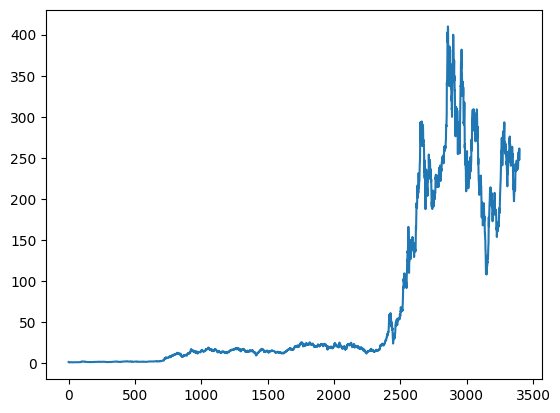

In [13]:
plt.plot(df.Close)

In [14]:
df

,Close,High,Low,Open,Volume
0,1.592667,1.666667,1.169333,1.266667,281494500
1,1.588667,2.028000,1.553333,1.719333,257806500
2,1.464000,1.728000,1.351333,1.666667,123282000
3,1.280000,1.540000,1.247333,1.533333,77097000
4,1.074000,1.333333,1.055333,1.333333,103003500
...,...,...,...,...,...
3395,252.539993,258.220001,251.369995,256.760010,93370100
3396,256.609985,257.970001,252.910004,254.490005,86892400
3397,261.440002,263.339996,257.519989,258.350006,106494400
3398,253.179993,265.130005,252.710007,263.660004,113619900


In [15]:
ma100=df.Close.rolling(100).mean()
ma100

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
3395    241.505100
3396    241.477999
3397    241.553799
3398    241.571099
3399    241.558899
Name: Close, Length: 3400, dtype: float64

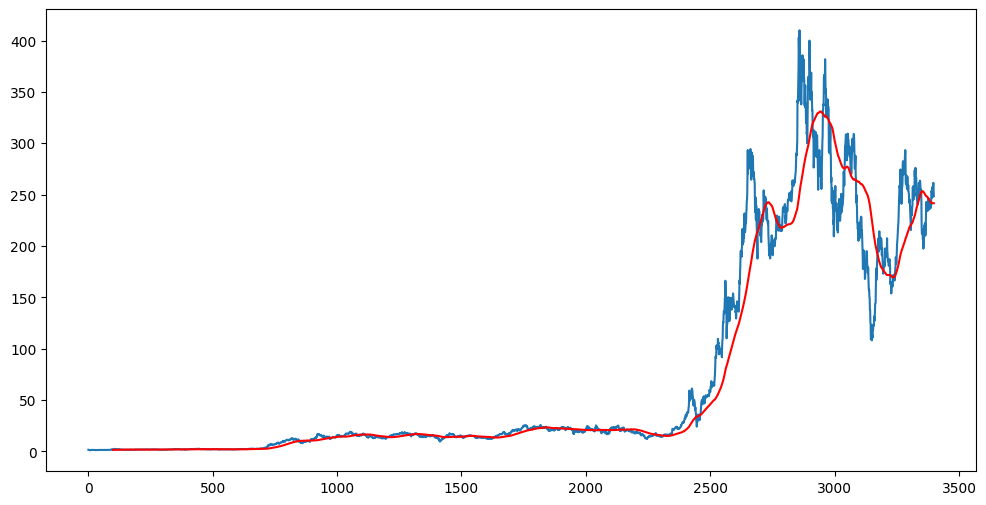

In [16]:
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')

In [17]:
ma200=df.Close.rolling(200).mean()
ma200

0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
          ...    
3395    227.70775
3396    228.12360
3397    228.55840
3398    228.90800
3399    229.24815
Name: Close, Length: 3400, dtype: float64

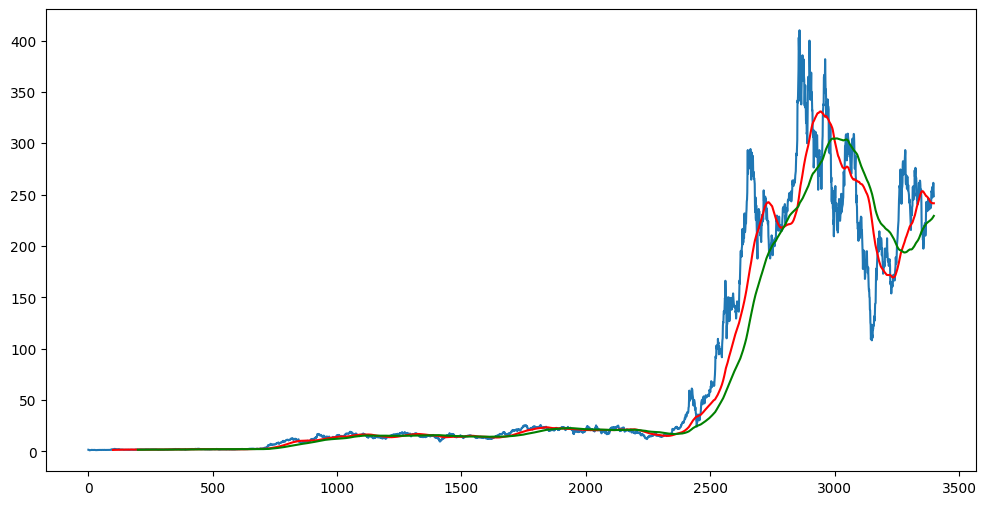

In [18]:
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.plot(ma200, 'g')

In [19]:
df.shape

(3400, 5)

In [20]:
data_training = pd.DataFrame(df['Close'][0:int(len(df) * 0.70)])  #splitting done hereee
data_testing=pd.DataFrame(df['Close'][int(len(df)*0.70):int(len(df))])

print(data_training.shape)
print(data_testing.shape)

(2380, 1)
(1020, 1)


In [21]:
data_training.head()

,Close
0,1.592667
1,1.588667
2,1.464000
3,1.280000
4,1.074000


In [22]:
data_testing.head()

,Close
2380,23.513332
2381,23.978666
2382,23.892668
2383,25.433332
2384,25.266001


In [23]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))


In [24]:
data_training_array=scaler.fit_transform(data_training)
data_training_array

array([[0.02191227],
       [0.02174975],
       [0.01668473],
       ...,
       [0.86698267],
       [0.87684173],
       [0.90205848]], shape=(2380, 1))

In [25]:
x_train=[]
y_train=[]
for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [26]:
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, LSTM

model = Sequential([
    Input(shape=(x_train.shape[1], 1)),   # Define input layer explicitly
    LSTM(50, activation='relu', return_sequences=True),
    Dropout(0.2),

    LSTM(60, activation='relu', return_sequences=True),
    Dropout(0.3),

    LSTM(80, activation='relu', return_sequences=True),
    Dropout(0.3),

    LSTM(120, activation='relu'),
    Dropout(0.5),

    Dense(1)
])


In [27]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 50)             │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100, 50)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 100, 60)             │          26,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 100, 60)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 100, 80)             │          45,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 100, 80)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 120)                 │          96,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 120)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             121 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(optimizer='adam',loss='mean_squared_error')
model.fit(x_train, y_train, epochs = 50)

Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step - loss: 0.0488
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - loss: 0.0110
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0107
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - loss: 0.0091
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 116ms/step - loss: 0.0101
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - loss: 0.0089
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 118ms/step - loss: 0.0083
Epoch 8/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 118ms/step - loss: 0.0080
Epoch 9/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step - loss: 0.0071
Epoch 10/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 118ms/step - loss: 0.0069
Epoch 11/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 119ms/step - loss: 0.0065
Epoch 12/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 121ms/step - loss: 0.0063
Epoch 13/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 122ms/step - loss: 0.0067
Epoch 14/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step - loss: 0.0067
Epoch 15/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 119ms/step - l

In [29]:
model.save('keras_model.keras')

In [30]:
model.save('keras_model1.keras')

In [31]:
data_testing.head()

,Close
2380,23.513332
2381,23.978666
2382,23.892668
2383,25.433332
2384,25.266001


In [32]:
data_training.tail(100)

,Close
2280,17.045334
2281,17.344667
2282,17.658667
2283,15.254667
2284,15.202667
...,...
2375,22.202000
2376,22.024668
2377,22.392668
2378,22.635332


In [33]:
past_100_days=data_training.tail(100)

In [35]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)


In [36]:
final_df.head()

,Close
0,17.045334
1,17.344667
2,17.658667
3,15.254667
4,15.202667


In [37]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.00745687],
       [0.008213  ],
       [0.00900617],
       ...,
       [0.62480739],
       [0.60394228],
       [0.59206991]], shape=(1120, 1))

In [38]:
input_data.shape

(1120, 1)

In [39]:
x_test=[]
y_test=[]

for i in range(100,input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i,0])
    

In [40]:
x_test,y_test=np.array(x_test),np.array(y_test)
print(x_test.shape)
print(y_test.shape)


(1020, 100, 1)
(1020,)


In [41]:
# PREDICTIONNNN!!!!
y_predicted=model.predict(x_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step


In [42]:
y_predicted.shape

(1020, 1)

In [43]:
y_test

array([0.02379529, 0.02497074, 0.0247535 , ..., 0.62480739, 0.60394228,
       0.59206991], shape=(1020,))

In [44]:
y_predicted

array([[0.05886146],
       [0.05886552],
       [0.05886529],
       ...,
       [0.58691597],
       [0.58884627],
       [0.59016573]], shape=(1020, 1), dtype=float32)

In [45]:
scaler.scale_

array([0.00252604])

In [46]:
scale_factor=1/0.00252604
y_predicted=y_predicted*scale_factor
y_test=y_test*scale_factor

Text(0, 0.5, 'Price')

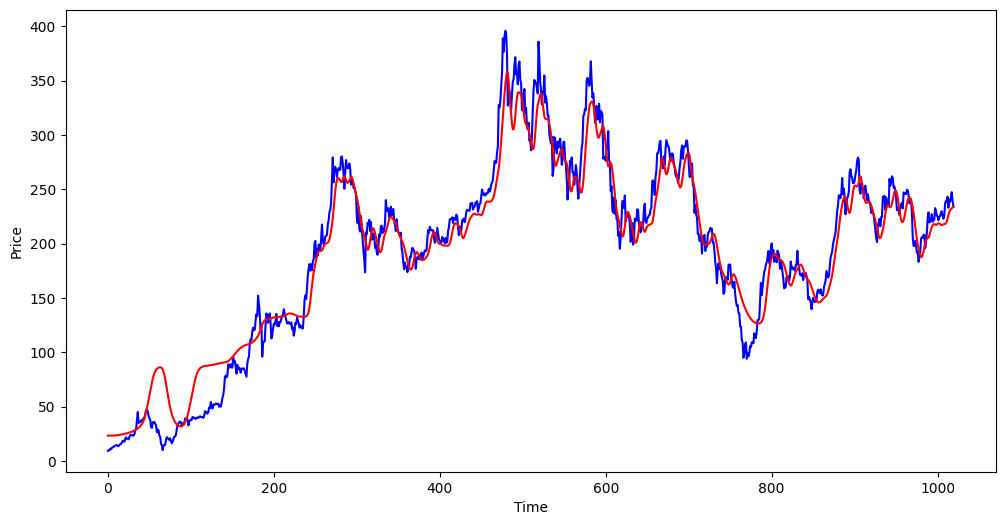

In [47]:
plt.figure(figsize=(12,6))
plt.plot(y_test,'b',label = 'Original Price')
plt.plot(y_predicted,'r',label = 'Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')

NameError: name 'st' is not defined